In [7]:
import os, sys
# sys.path.append("/ssd/users/wergillius/Project/diffuse_differentiate")

import PATH
import scanpy as sc
from importlib import reload

import numpy as np

from src import _sampler
from src import _reader

import torch
from torch import nn

from matplotlib import pyplot as plt

reload(PATH)

# <font color='#008000'> Norman data

norman anndata processed by CPA

In [8]:
data_dir = "/data/users/wergillius/CPA+GEARS/cpa_datasets"
data_path = 'Norman2019_prep_new.h5ad'
norman_cdata = sc.read(os.path.join(data_dir, data_path))

In [10]:
sc.pp.neighbors(norman_cdata)

         Falling back to preprocessing with `sc.pp.pca` and default params.


In [13]:
sc.tl.umap(norman_cdata)

In [75]:
sc.tl.leiden(norman_cdata)

In [342]:
print(norman_cdata.obsp['connectivities'][0])

  (0, 6353)	0.38583165
  (0, 9827)	0.12210729
  (0, 13912)	0.29894093
  (0, 16378)	0.11417513
  (0, 37305)	0.43961683
  (0, 38361)	0.24662405
  (0, 40250)	0.6896623
  (0, 44788)	0.059832133
  (0, 46915)	0.10211528
  (0, 51582)	0.17821462
  (0, 56554)	0.20543583
  (0, 63564)	0.060495473
  (0, 66001)	1.0
  (0, 67125)	0.2038688
  (0, 70503)	0.32939664
  (0, 77788)	0.12187031
  (0, 81376)	0.30452403
  (0, 85099)	0.065191396
  (0, 85930)	0.31088108
  (0, 88340)	0.2876359
  (0, 89284)	0.22320493
  (0, 91813)	0.2251227
  (0, 101577)	0.17344765


In [234]:
norman_cdata.X.mean(axis=0).max()

5.212412

In [224]:
from sklearn.preprocessing import StandardScaler

In [223]:
 StandardScaler().fit(norman_cdata.X)

<108497x5000 sparse matrix of type '<class 'numpy.float32'>'
	with 46692457 stored elements in Compressed Sparse Row format>

In [145]:
norman_cdata.var['dispersions']

index
ENSG00000239945    0.821591
ENSG00000223764    0.453863
ENSG00000187634    0.826190
ENSG00000187583    0.433592
ENSG00000188290    0.438797
                     ...   
ENSG00000212907    0.447014
ENSG00000198886    2.171050
ENSG00000198695    1.058854
ENSG00000198727    1.677951
ENSG00000278633    0.895332
Name: dispersions, Length: 5000, dtype: float64

In [144]:
len(norman_cdata.uns['condition_colors'])

284

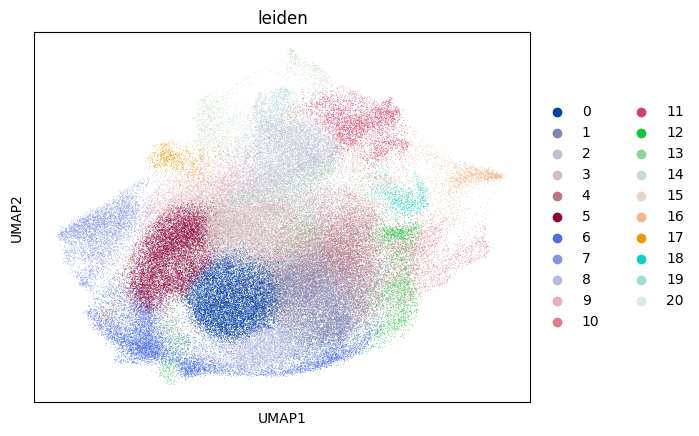

In [143]:
sc.pl.umap(norman_cdata, color=['leiden'])

In [20]:
norman_cdata.obs['numeric_index'] = np.arange(0,108497)

In [35]:
var_iloc_ls=norman_cdata.var['gene_symbols'].index.tolist()

def DEG_iloc_for_group(cond):
    DEGs = norman_cdata.uns['rank_genes_groups_cov'][cond]
    var_ilocs = [var_iloc_ls.index(var) for var in DEGs]
    return var_ilocs

In [40]:
gene_ilocs = DEG_iloc_for_group('A549_AHR+KLF1_1+1')
DEGs = norman_cdata.uns['rank_genes_groups_cov']['A549_AHR+KLF1_1+1']

In [41]:
DEGs

array(['ENSG00000034510', 'ENSG00000130656', 'ENSG00000196565',
       'ENSG00000141744', 'ENSG00000105610', 'ENSG00000100097',
       'ENSG00000142227', 'ENSG00000206172', 'ENSG00000213934',
       'ENSG00000197747', 'ENSG00000182718', 'ENSG00000163191',
       'ENSG00000005249', 'ENSG00000090013', 'ENSG00000142669',
       'ENSG00000147454', 'ENSG00000102575', 'ENSG00000160789',
       'ENSG00000158869', 'ENSG00000069482'], dtype=object)

In [42]:
len(gene_ilocs)

20

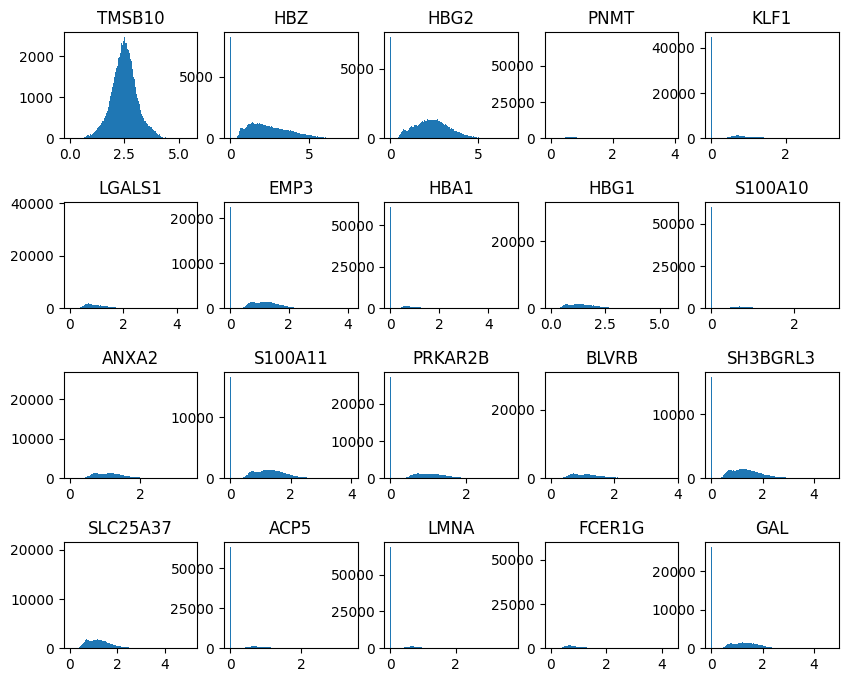

In [43]:
fig, axs = plt.subplots(4, 5, figsize=(10,8), dpi=100, gridspec_kw={"hspace":0.6})
axs = axs.flatten()
for i, gene_iloc in enumerate(gene_ilocs):
    ax = axs[i]
    ax.hist(norman_cdata.X[:,gene_iloc].todense(), bins=200);
    ax.set_title(norman_cdata.var.loc[DEGs[i],'gene_symbols'])

preprocessed by Gears

```python
data_dir = "/data/users/wergillius/CPA+GEARS/gear_datasets/"
data_path = 'norman/perturb_processed.h5ad'
norman_gdata = sc.read(os.path.join(data_dir, data_path))
```

# beta and alphas

### the influence of ß scheduler hyper-parameters


$\sqrt{\bar{\alpha}_t} \mathbf{x}_0 + \sqrt{(1- \bar{\alpha}_t)  } \mathbf{\epsilon}$. 

$q(\mathbf{x}_t | \mathbf{x}_0) = \cal{N}(\mathbf{x}_t; \sqrt{\bar{\alpha}_t} \mathbf{x}_0, (1- \bar{\alpha}_t) \mathbf{I})$

In [241]:
def draw_alpha_schedule(a_dict, label='start', figtitle=None):
    fig, axs = plt.subplots(1,2, figsize=(5,2), dpi=400, gridspec_kw={"wspace":0.5})
    # sqrt_alpha_prod
    ax = axs[0]
    ax.set_ylabel(r"$\sqrt{\bar \alpha_t}$")
    ax.set_xlabel("timestep")
    for k,v in a_dict.items():
        ax.plot(v[0],  alpha=0.6)

    ax = axs[1]
    ax.set_ylabel(r"$\sqrt{1 - \bar \alpha_t}$")
    ax.set_xlabel("timestep")
    for k,v in a_dict.items():
        ax.plot(v[1], label=r'%s'%label + k,  alpha=0.6)
    ax.legend(ncol=1, fontsize=6, bbox_to_anchor=[1.4,0.45,0.3,0.4])
    
    if figtitle is not None:
        fig.suptitle(figtitle)

#### linear  
  
- beta_start
- beta_end

In [248]:
# fix end to 0.02 (defualt) and see the influence of beta start
linear_sqrt_a_dict = {}
for s in [1e-20, 1e-8, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 0.1,1]:
    DDPM = _sampler.DDPM_Sampler(model=None, timesteps=200,
                                 scheduler="linear_beta_schedule", 
                                 loss_type='huber', beta_start=s , beta_end=0.04)
    linear_sqrt_a_dict[str(s)] = DDPM.sqrt_a_bar, DDPM.sqrt_1_a_bar

# fix end to 0.02 (defualt) and see the influence of beta start
linear_sqrt_a_dict_end = {}
for s in [2e-8, 2e-6, 2e-5, 2e-4, 2e-3, 2e-2, 0.2,2]:
    DDPM = _sampler.DDPM_Sampler(model=None, timesteps=600,
                                 scheduler="linear_beta_schedule", 
                                 loss_type='huber', beta_start=1e-4 , beta_end=s)
    linear_sqrt_a_dict_end[str(s)] = DDPM.sqrt_a_bar, DDPM.sqrt_1_a_bar

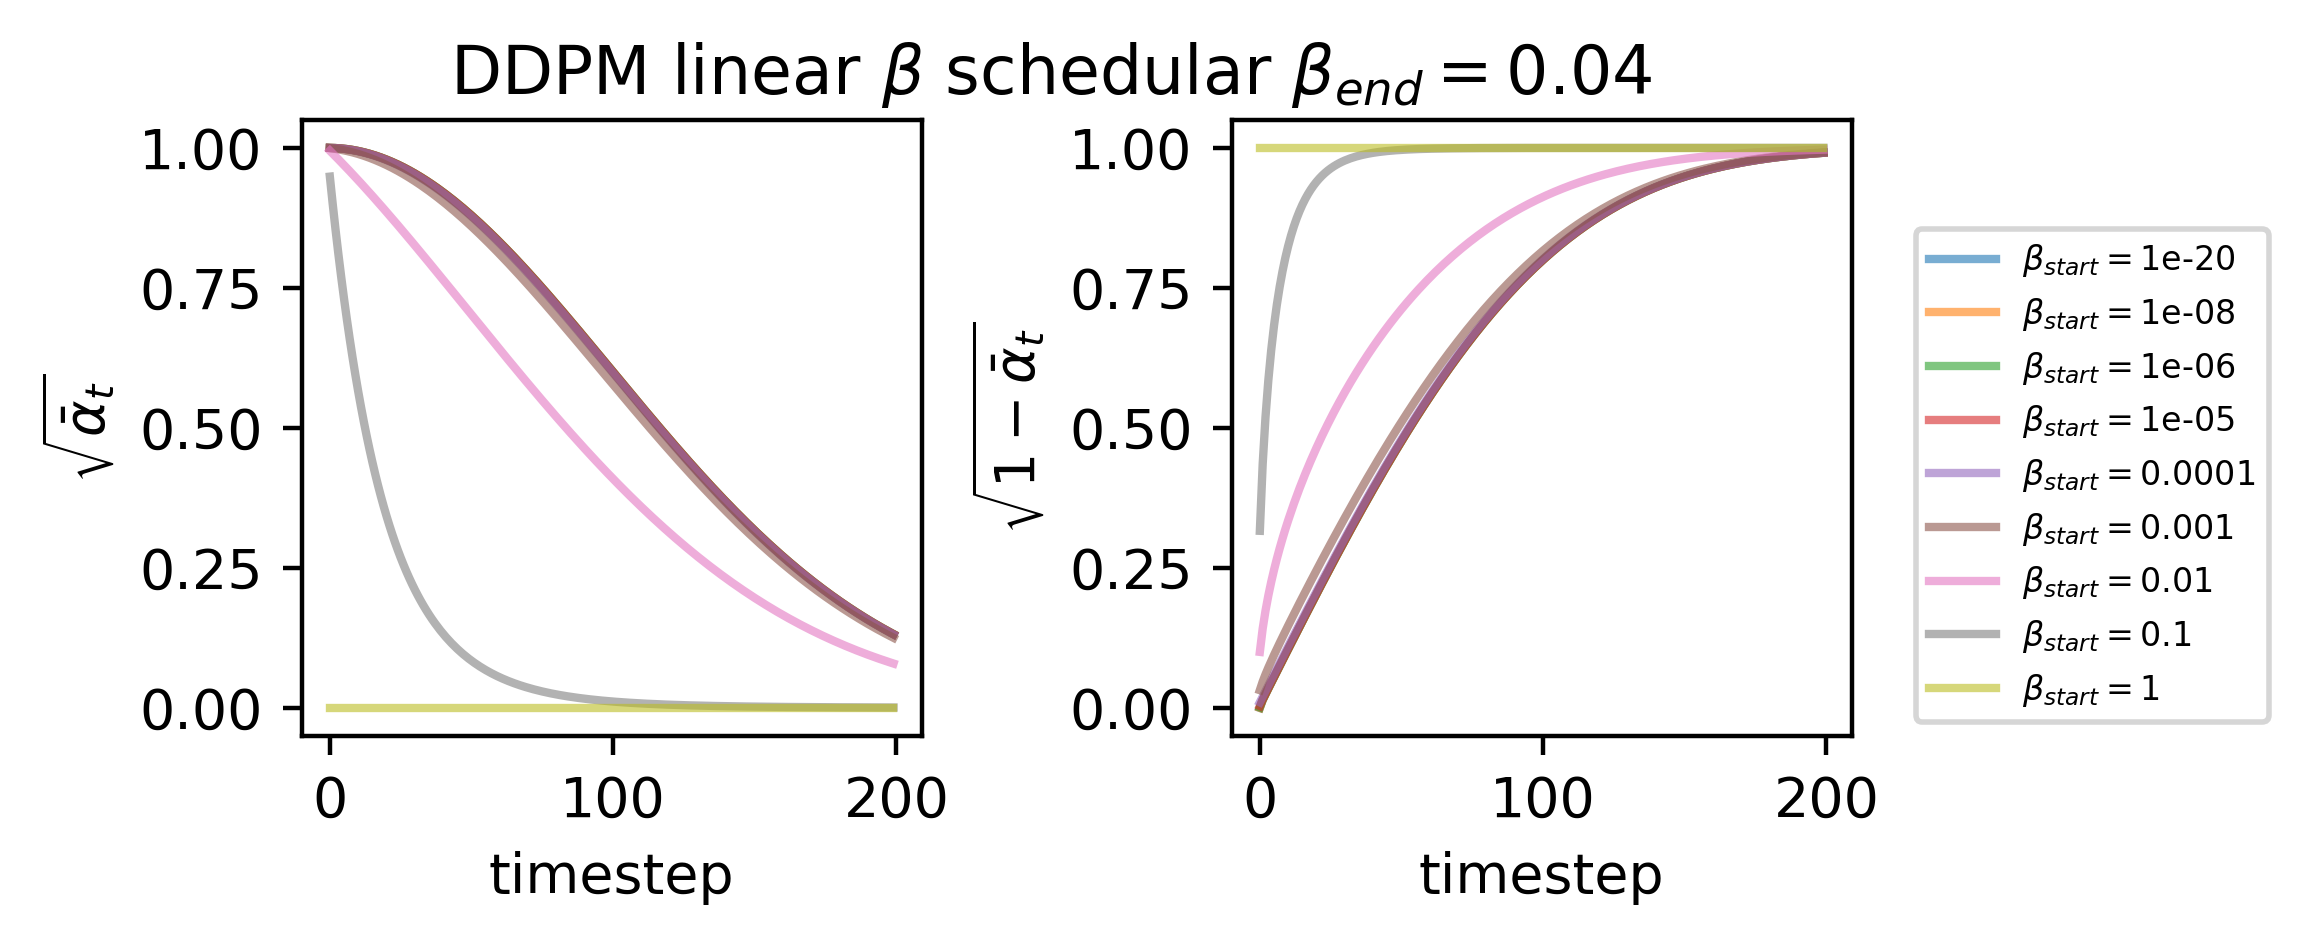

In [254]:
draw_alpha_schedule(linear_sqrt_a_dict, r'$\beta_{start} = $', r'DDPM linear $\beta$ schedular $\beta_{end} = 0.04$')

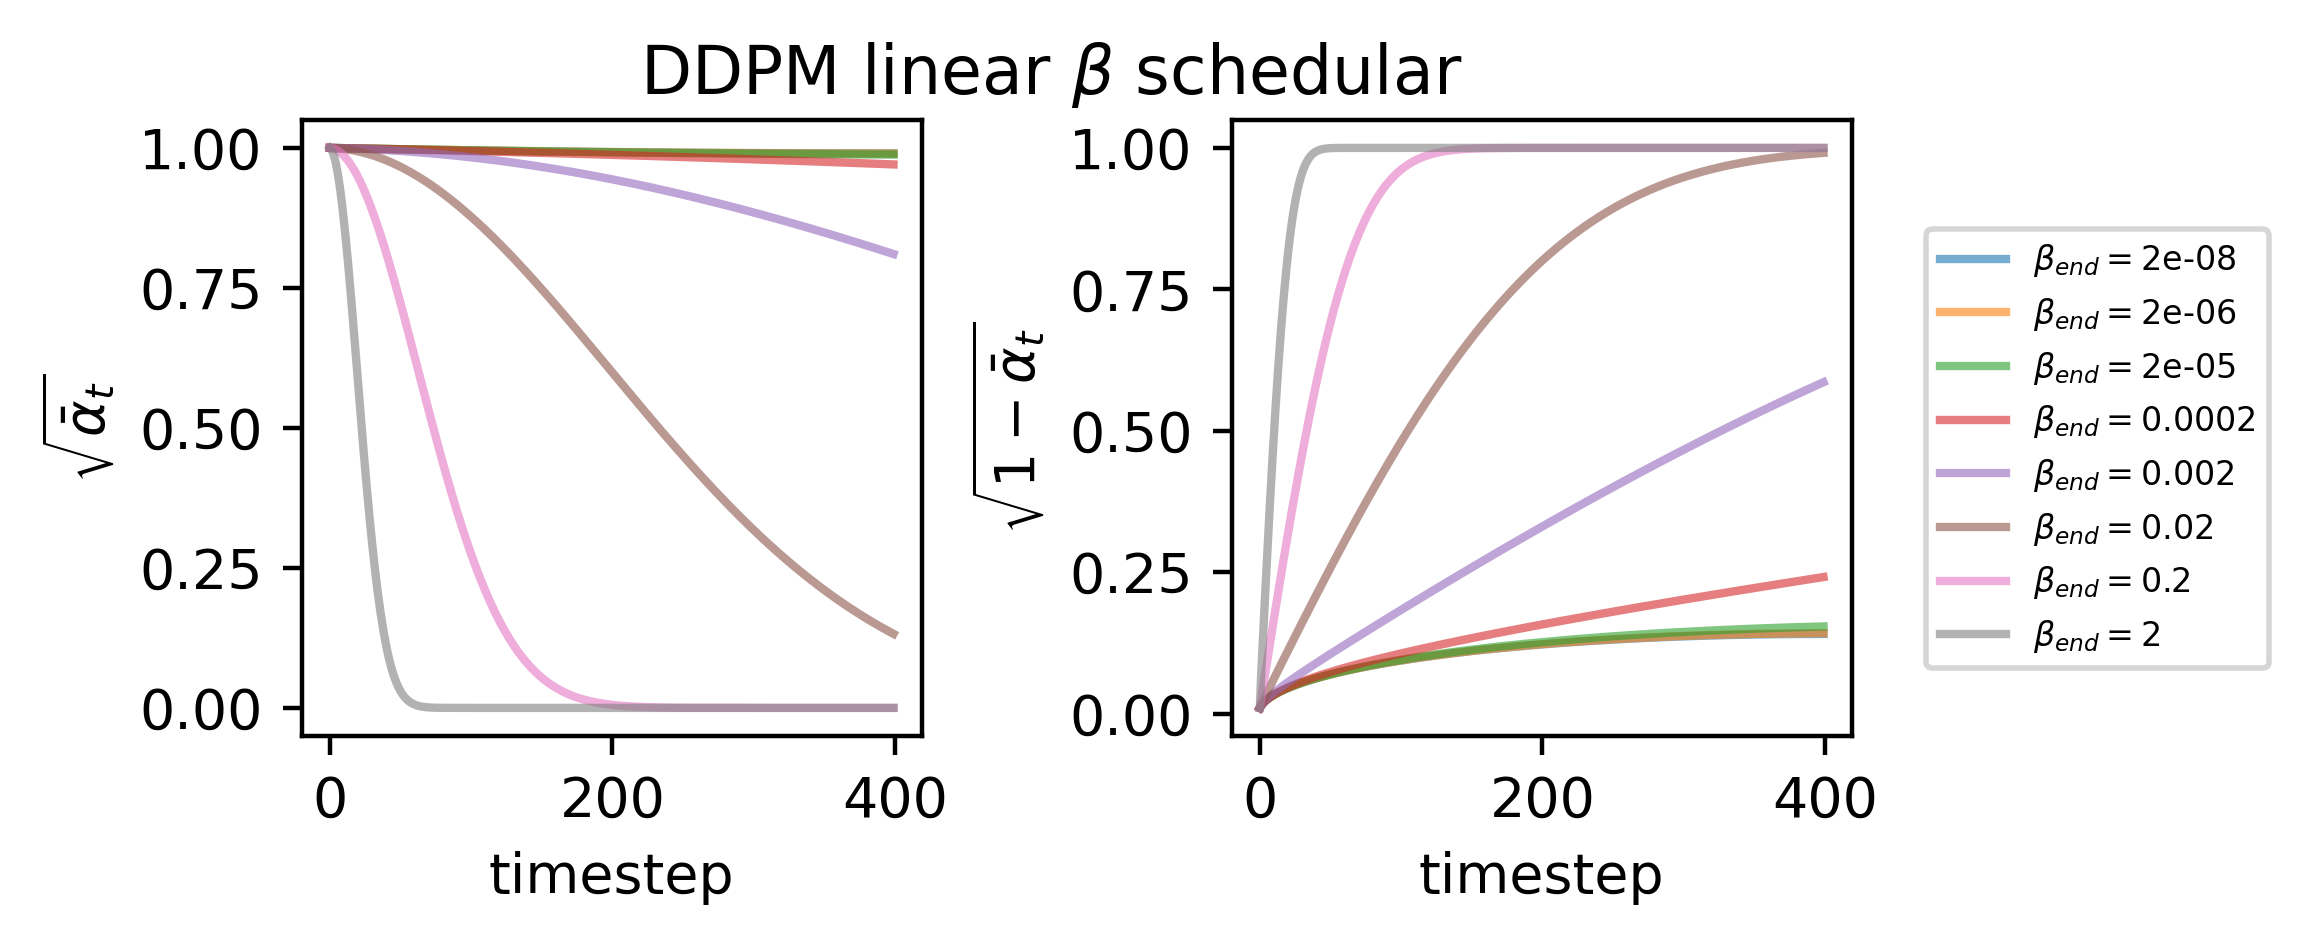

In [243]:
draw_alpha_schedule(linear_sqrt_a_dict_end, r'$\beta_{end} = $', r'DDPM linear $\beta$ schedular')

#### cosine 

- s

In [152]:
# fix end to 0.02 (defualt) and see the influence of beta start
cosine_sqrt_a_dict = {}
hyper_params = np.array([1e-20, 1e-8, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 0.1])
for s in hyper_params*8:
    DDPM = _sampler.DDPM_Sampler(model=eps_net, timesteps=400,
                                 scheduler="cosine_beta_schedule", 
                                 loss_type='huber', s=s )
    cosine_sqrt_a_dict[str(s)] = DDPM.sqrt_a_bar, DDPM.sqrt_1_a_bar

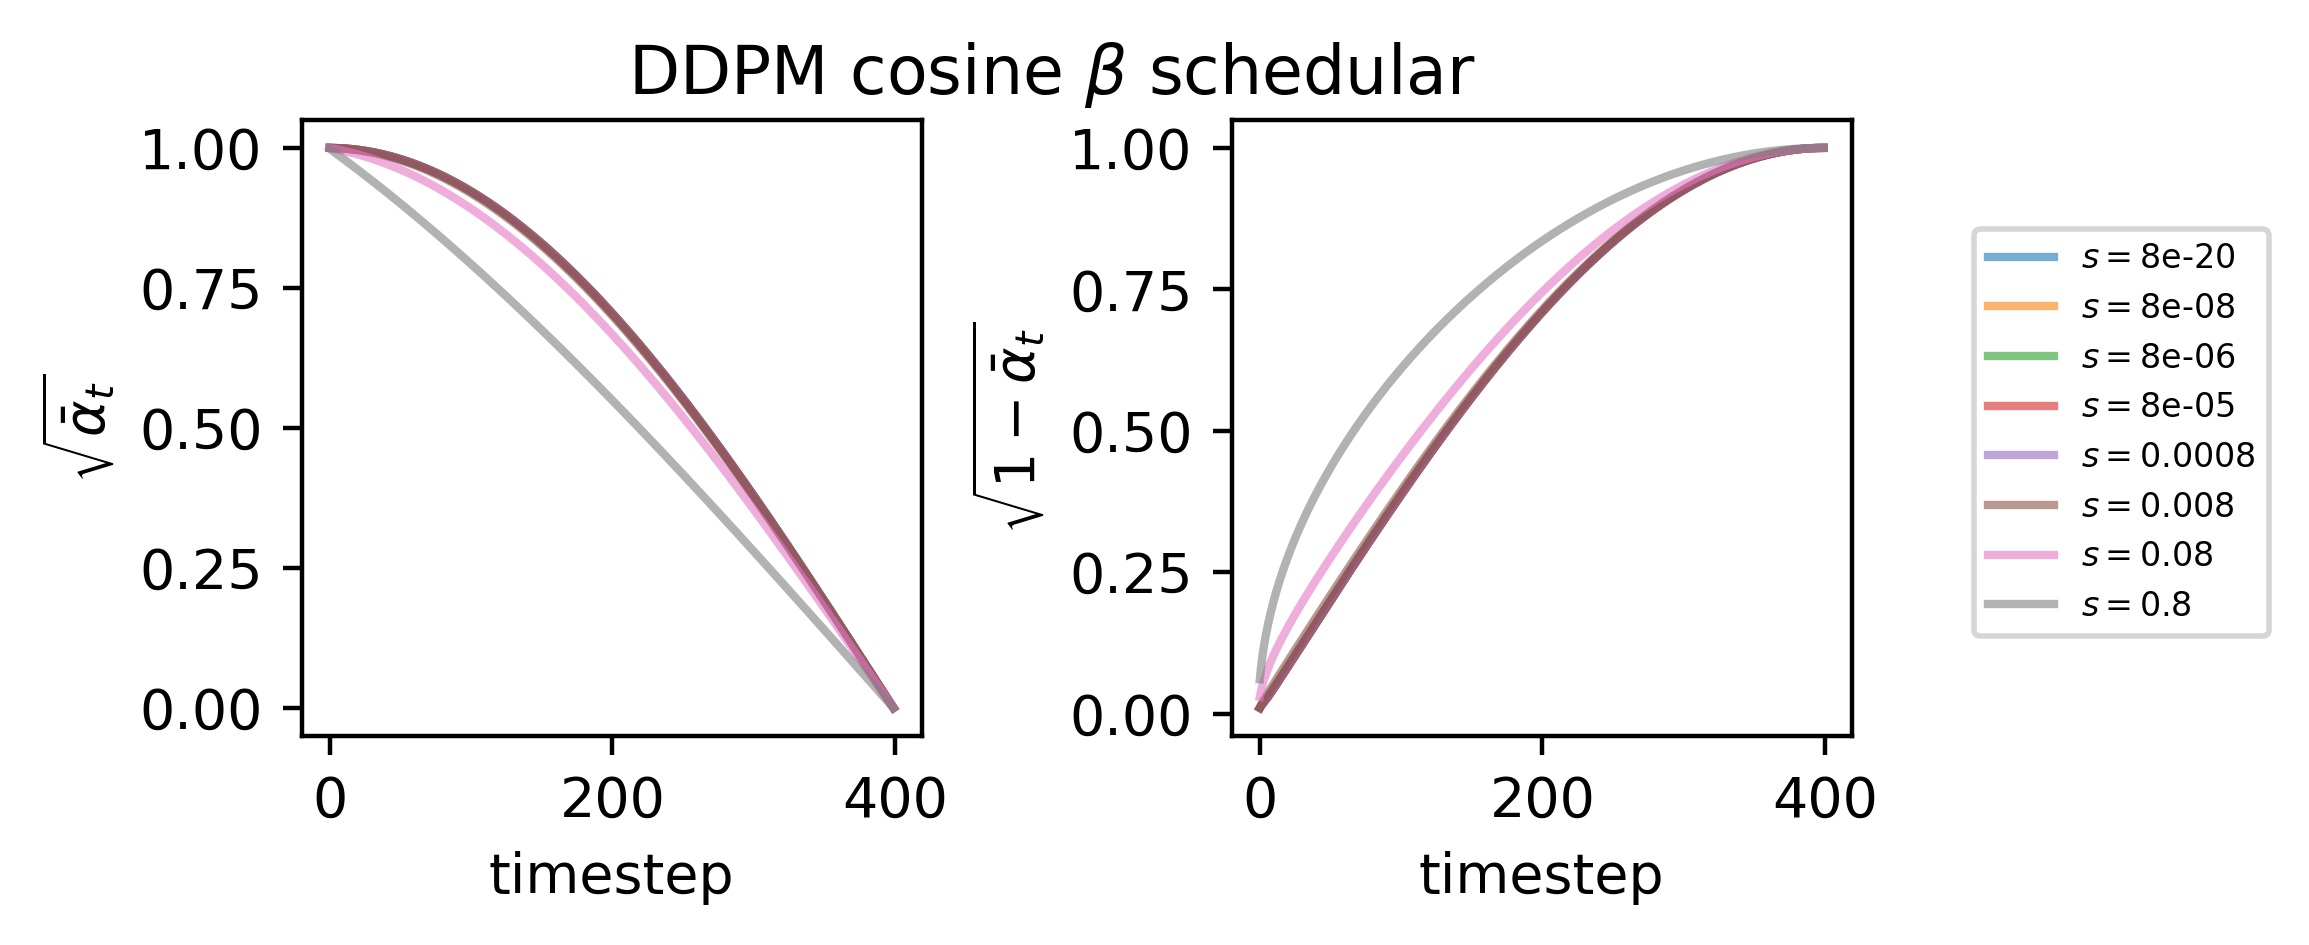

In [155]:
draw_alpha_schedule(cosine_sqrt_a_dict, 's', r'DDPM cosine $\beta$ schedular')

# test model prediction

In [161]:
from torch.utils.data import DataLoader

create `unique_token_dict`

In [162]:
norman_cdata.obs['pert1'] = norman_cdata.obs['condition'].apply(lambda x: x.split("+")[0])
norman_cdata.obs['pert2'] = norman_cdata.obs['condition'].apply(lambda x: x.split("+")[-1])
# unique tokens
unique_token = list(set(norman_cdata.obs['pert1'].tolist() + norman_cdata.obs['pert2'].tolist()))
unique_token.remove('ctrl')
unique_token = ['ctrl'] + unique_token
unique_token_dict = {token:i for i, token in enumerate(unique_token)}

In [163]:
# call dataset class and wrap to loader
train_set = _reader.Condition_AnnDataSet(norman_cdata, unique_token_dict)
train_dl = iter(DataLoader(train_set, batch_size=32, shuffle=True))

In [164]:
# create mini-batch
def return_next_batch(t=None):
    X, c = next(train_dl)
    #if specify a timestep t
    if t:
        T_b = torch.full((32,), t).long()
    else:
        T_b = torch.from_numpy(np.random.randint(0, 400, (32,)))
    Exp_batch = None
    return X, T_b, Exp_batch, c

<font size=4 color='orange'>**Is prediction always zero ?**</font>

5 mini-batch  
Both instances and time are randomly drawed from distribution

In [290]:
# load model
save_path = "/data/users/wergillius/diffuse_differentiate/Epsilon_Linear/debug_linear.pth"
eps_net = torch.load(save_path, map_location='cpu')

DDPM = _sampler.DDPM_Sampler(model=eps_net, timesteps=200,
                                 scheduler="linear_beta_schedule", 
                                 loss_type='huber') # use default s=0.08

In [165]:
pred = []
for i in range(5):
    with torch.no_grad():
        mini_batch = return_next_batch()
        pred.append(eps_net(*mini_batch).numpy())

5 mini-batch  
Instances are random; timestep is fixed to 4

In [166]:
time_fix_pred = []
for i in range(5):
    with torch.no_grad():
        mini_batch = return_next_batch(t=4)
        time_fix_pred.append(eps_net(*mini_batch).numpy())

In [167]:
time_fix_pred[0][0] - time_fix_pred[1][0]

array([-0.01979708,  0.03456236, -0.03050522, ..., -0.00029903,
       -0.00010902,  0.0449431 ], dtype=float32)

In [168]:
time_fix_pred[0][0] - time_fix_pred[0][1]

array([ 0.01995452, -0.00625082, -0.01649033, ..., -0.00080376,
        0.00028111,  0.01259709], dtype=float32)

5 mini-batch  
Instances are fixed; timestep is chronologically sampled

In [169]:
sample_fix_pred = []
X, T_b, Exp_batch, c = return_next_batch()
for i in range(0, 400, 80):
    with torch.no_grad():
        T_b = torch.full((32,), i).long()
        sample_fix_pred.append(eps_net(X, T_b, Exp_batch, c).numpy())

In [292]:
sample_fix_pred[0].mean()

5.189464e-05

In [298]:
np.sum(sample_fix_pred[0][0] - sample_fix_pred[0][1])

-1.5676192

# Value range of the loss

In [171]:
act_fn = nn.SmoothL1Loss()

In [172]:
for i in range(10):
    noise1 = torch.randn((32,5000)).float()
    noise2 = torch.randn((32,5000)).float()
    print(act_fn(noise1, noise2))

tensor(0.7184)
tensor(0.7188)
tensor(0.7211)
tensor(0.7175)
tensor(0.7218)
tensor(0.7208)
tensor(0.7210)
tensor(0.7182)
tensor(0.7187)
tensor(0.7201)


In [173]:
pure_zeros = torch.zeros((32,5000)).float()
for i in range(10):
    noise = torch.randn((32,5000)).float()
    print(act_fn(pure_zeros, noise))

tensor(0.4245)
tensor(0.4231)
tensor(0.4239)
tensor(0.4229)
tensor(0.4242)
tensor(0.4260)
tensor(0.4247)
tensor(0.4225)
tensor(0.4267)
tensor(0.4260)


# Visualize X

## generate a example data

In [178]:
example_conds = ['A549_SGK1+ctrl_1+1', 'A549_BCORL1+ctrl_1+1', 'A549_FOXL2+ctrl_1+1', 'A549_KLF1+ctrl_1+1'] 

# sample 1+1 
sampled_df = norman_cdata.obs.query("`cov_drug_dose_name` in @example_conds").sample(n=64)

In [179]:
sampled_df.sort_values(['cov_drug_dose_name'], inplace=True)

In [180]:
sampled_cellindex = sampled_df['numeric_index'].values

In [181]:
var_idx = []
for c in example_conds:
    var_idx += DEG_iloc_for_group(c)
    
sampled_var_idx = list(set(var_idx))
len(sampled_var_idx)

63

In [182]:
sample_mat = norman_cdata.X[sampled_cellindex][:, sampled_var_idx].todense()
sample_mat = np.asarray(sample_mat)
sample_mat.shape

(64, 63)

In [183]:
filter_cond1 = sample_mat.std(axis=0) > 0.5
filter_cond2 = np.logical_and(sample_mat.mean(axis=0) > 0, sample_mat.mean(axis=0) < 2.5)

joint_cond = np.logical_and(filter_cond1, filter_cond2)

filtered_sample_mat = sample_mat[:,joint_cond]
filtered_sample_mat.shape

(64, 33)

In [184]:
filtered_sample_mat.max()

5.1131105

In [185]:
def matss(mat,ax=None):
    if ax is None:
        plt.imshow(mat, aspect='auto', vmin=-1, vmax=3.8690238)
    else:
        ax.imshow(mat, aspect='auto', vmin=-1, vmax=3.8690238)

In [186]:
import seaborn as sns

In [187]:
sample_mat.shape

(64, 63)

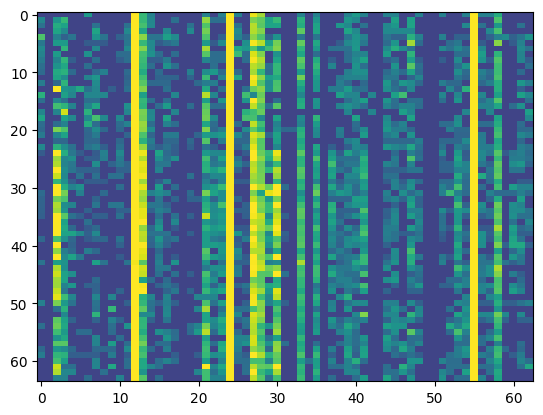

In [189]:
matss(sample_mat)

max value: 3.904137928925979


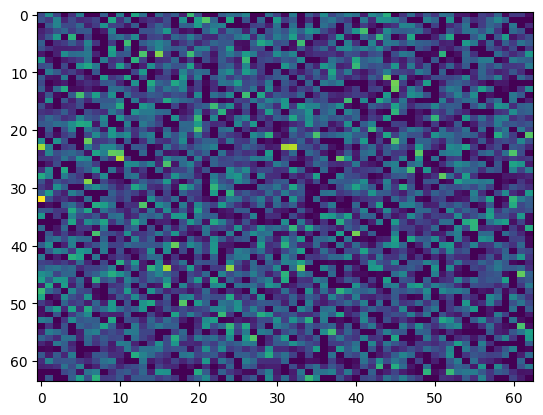

In [227]:
randomx = np.random.randn(*sample_mat.shape)
print("max value: {}".format( randomx.max() ))
matss(randomx)

## qsample using `example matrix`

In [191]:
sampled_df.columns

Index(['cov_drug_dose_name', 'dose_val', 'control', 'condition',
       'guide_identity', 'drug_dose_name', 'cell_type', 'split', 'split1',
       'split2', 'split3', 'split4', 'split5', 'split6', 'split7', 'split8',
       'split9', 'split10', 'split11', 'split12', 'split13', 'split14',
       'split15', 'split16', 'split17', 'split18', 'split19', 'split20',
       'split21', 'split22', 'split23', 'split24', 'split25', 'numeric_index',
       'leiden', 'pert1', 'pert2'],
      dtype='object')

In [304]:
c1 = sampled_df['pert1'].map(unique_token_dict).values.reshape(64,1)
c2 = np.zeros((64,1))

In [305]:
c = torch.from_numpy(np.concatenate([c1,c2], axis=1)).long()

In [306]:
X = torch.from_numpy(norman_cdata.X[sampled_cellindex].todense())

In [307]:
record_noise = [torch.randn(64, 5000) for i in range(400)]

## Visualize X

q sample  200 steps

In [325]:
leant_embedding = eps_net.embedder.weight.detach().cpu().numpy()

In [331]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

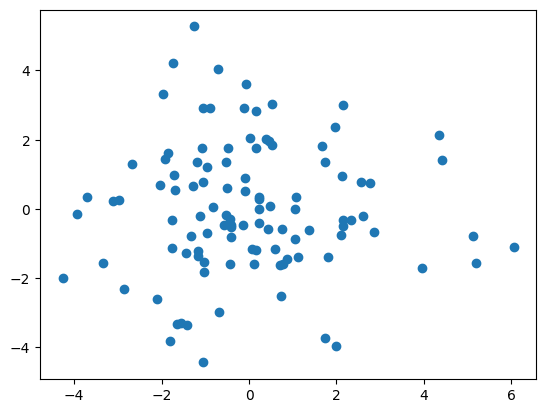

In [329]:
norm_emb_pca = PCA(n_components=50)
norm_emb50pc = norm_emb_pca.fit_transform(leant_embedding)
plt.scatter(norm_emb50pc[:,0], norm_emb50pc[:,1])

In [308]:
X_t = X
corruptd_Xs = [X]
clean_Xs = []

for t in range(200):
    # X_noise
    with torch.no_grad():
        T_b = torch.full((64,), t).long()
        X_t = DDPM.q_sample(X_t, T_b, noise=record_noise[t])
        corruptd_Xs.append(X_t.numpy())

        # denoise
        X_clean = DDPM.p_sample(X_t, T_b, batch=None, c=c)
        clean_Xs.append(X_clean.numpy())

sample from x dore

In [340]:
# here we don't start with random noise 
X_t = torch.from_numpy(corruptd_Xs[74])
reconstruct_X = []

for t in range(75,0,-1):
    with torch.no_grad():
        T_b = torch.full((64,), t).long()
        X_t = DDPM.p_sample(X_t, T_b, batch=None, c=c)
        reconstruct_X.append(X_t.numpy())

reconstruct_X = reconstruct_X[::-1]

In [310]:
# drop the last one , so that clean X an corruped X are aligned
corruptd_Xs = corruptd_Xs[:-1]

In [313]:
len(clean_Xs)

200

In [312]:
len(corruptd_Xs)

200

reverse from the corrupted X

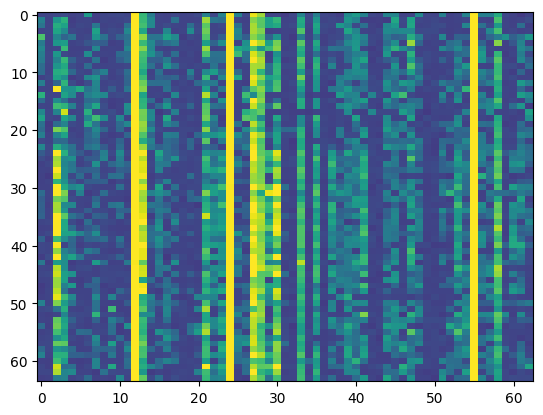

In [198]:
matss(corruptd_Xs[0][:, sampled_var_idx])

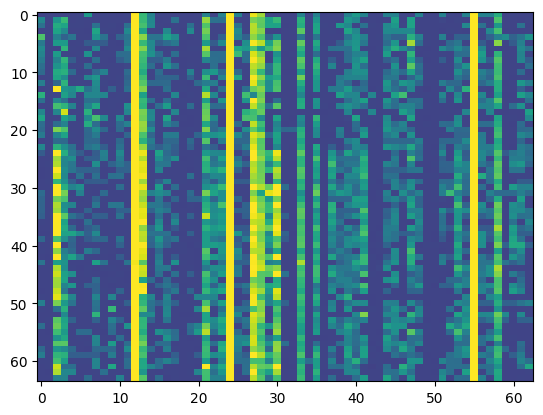

In [315]:
matss(clean_Xs[0][:, sampled_var_idx])

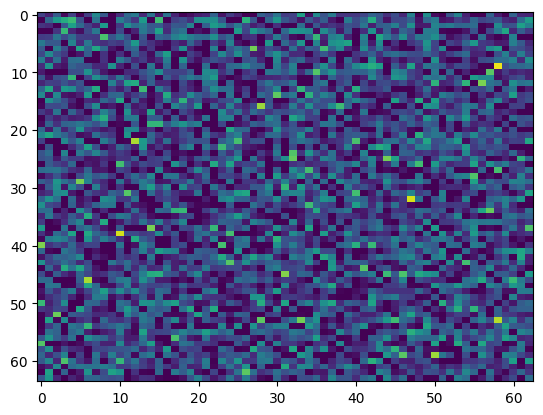

In [201]:
matss(corruptd_Xs[-1][:, sampled_var_idx])

the corruption along time $t$

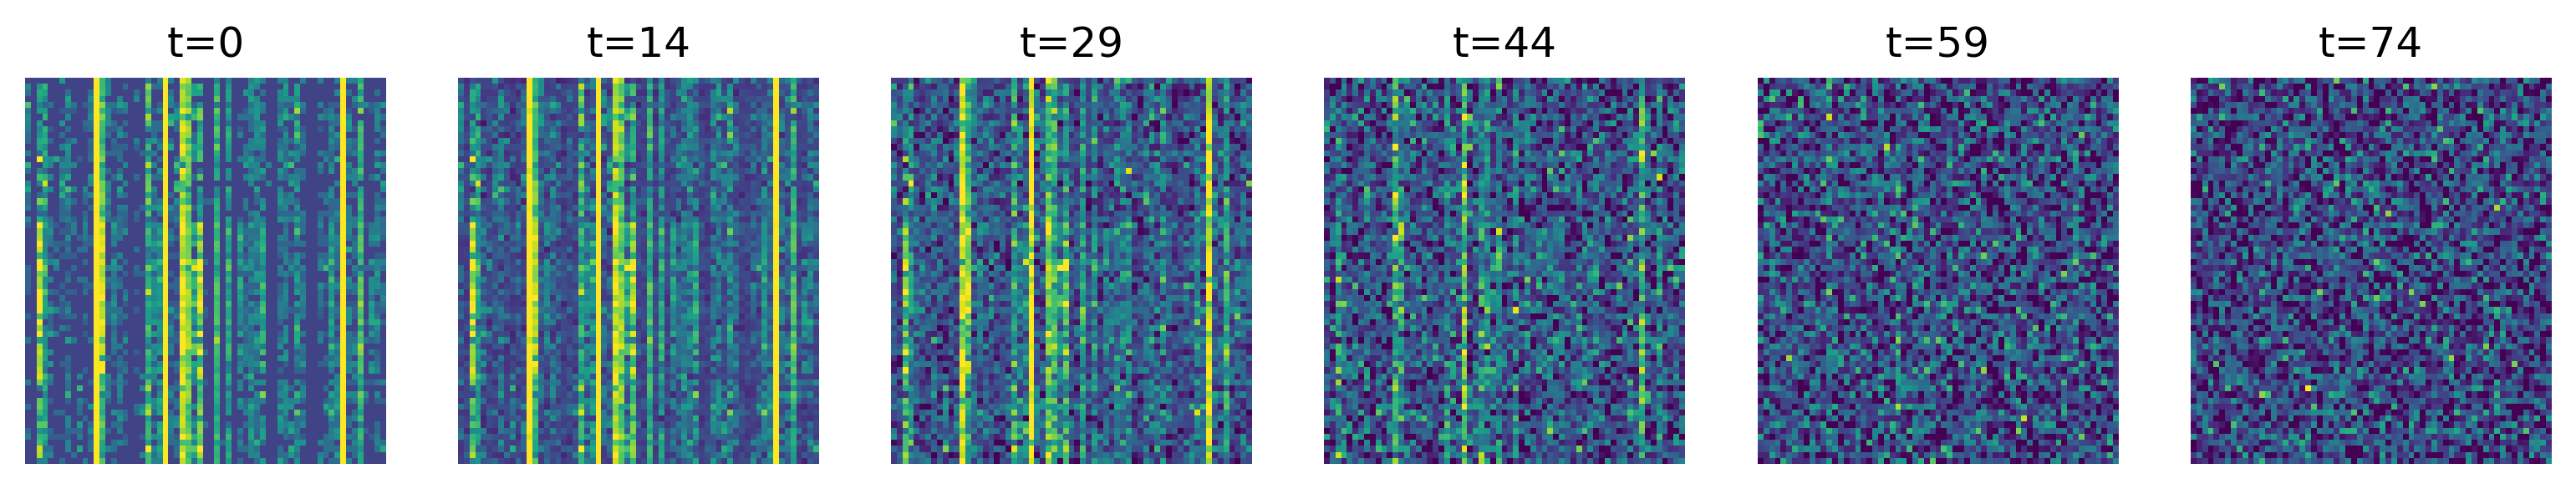

In [319]:
fig, axs = plt.subplots(1, 6, figsize=(13,2), dpi=300)
axs = axs.flatten()
for i in range(6):
    ax = axs[i]
    t = max(0, i * 15 -1)
    mat = corruptd_Xs[t][:, sampled_var_idx]
    matss(mat, ax)
    ax.set_title("t=%d"%t)
    ax.axis('off')

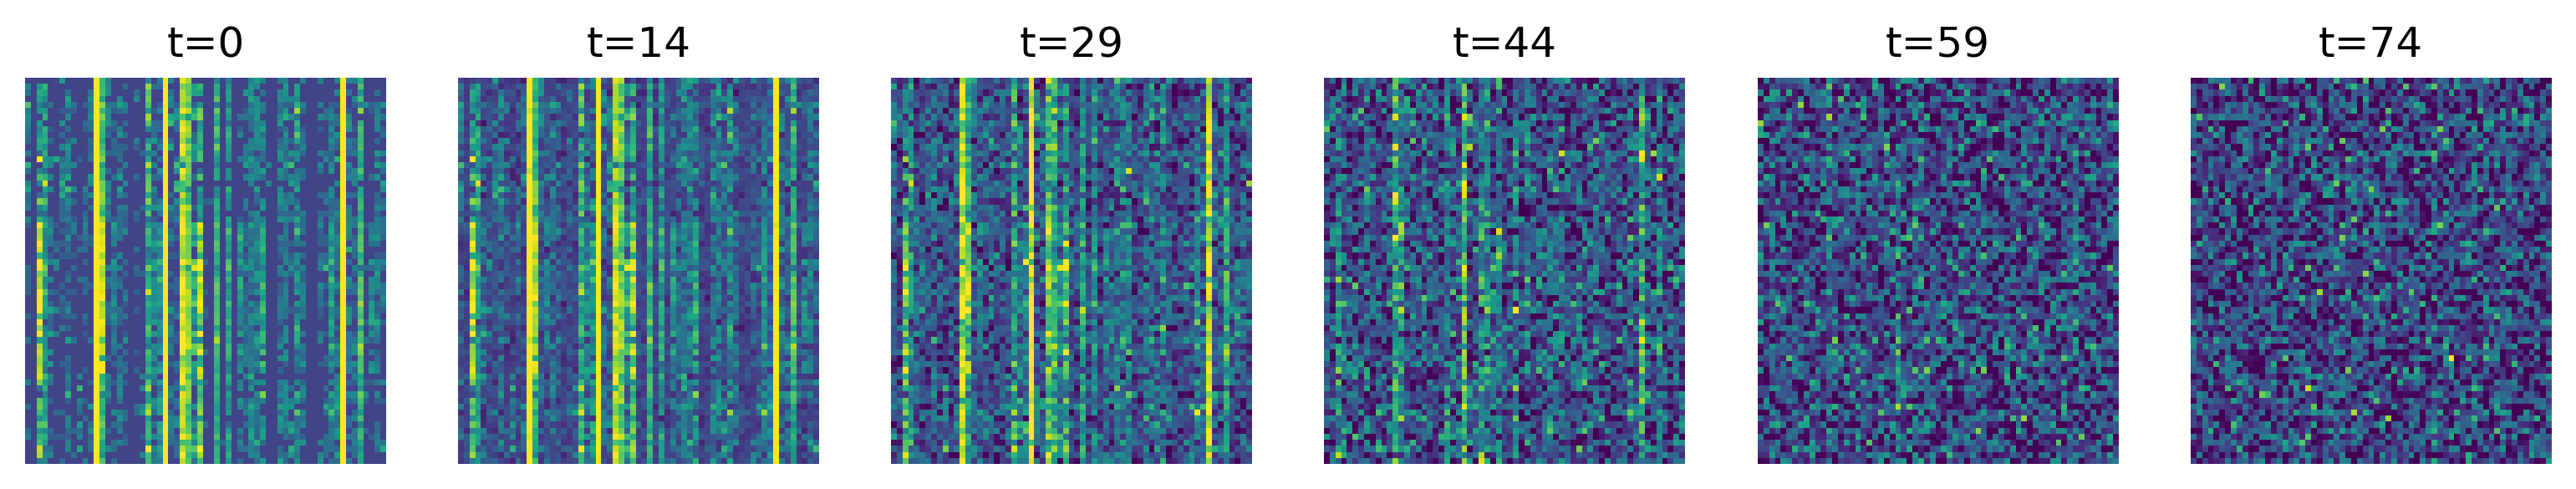

In [320]:
fig, axs = plt.subplots(1, 6, figsize=(13,2), dpi=300)
axs = axs.flatten()
for i in range(6):
    ax = axs[i]
    t = max(0, i * 15 -1)
    mat = clean_Xs[t][:, sampled_var_idx]
    matss(mat, ax)
    ax.set_title("t=%d"%t)
    ax.axis('off')

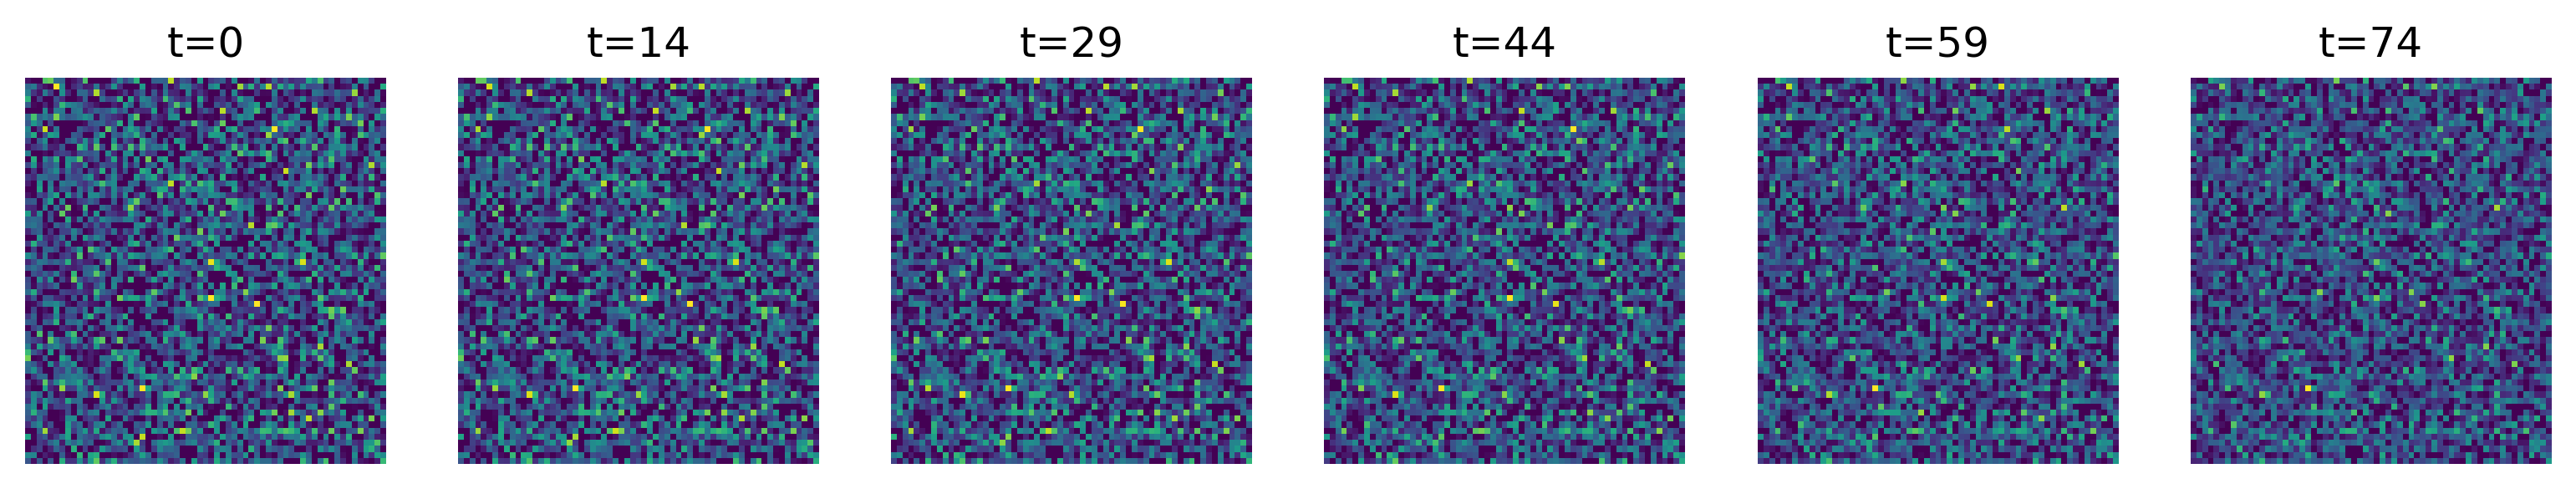

In [341]:
fig, axs = plt.subplots(1, 6, figsize=(13,2), dpi=300)
axs = axs.flatten()
for i in range(6):
    ax = axs[i]
    t = max(0, i * 15 -1)
    mat = reconstruct_X[t][:, sampled_var_idx]
    matss(mat, ax)
    ax.set_title("t=%d"%t)
    ax.axis('off')

Is the final `X` a standard gaussian ? 

In [208]:
corruptd_Xs[124][:, sampled_var_idx].std(axis=0)

array([1.1155821 , 1.0965773 , 1.1040064 , 0.9291285 , 1.0178039 ,
       0.99550766, 0.9573509 , 0.9983784 , 0.94909376, 1.0892615 ,
       1.0671793 , 0.972556  , 0.85437006, 1.0675007 , 0.8795557 ,
       1.1943375 , 0.9763585 , 0.85951185, 0.9652995 , 1.0233871 ,
       1.1527438 , 0.92890954, 0.87302804, 0.97353965, 1.0261211 ,
       0.8982822 , 1.1025326 , 0.95900744, 1.0577725 , 0.9784235 ,
       1.061942  , 1.2149355 , 1.0346285 , 0.9659733 , 0.9070352 ,
       1.1492229 , 0.9944531 , 1.0195566 , 0.8928607 , 1.0597954 ,
       1.015507  , 1.1453817 , 0.8924699 , 1.0715573 , 1.0553616 ,
       1.1098735 , 1.0569013 , 0.9898857 , 0.97988445, 0.97842747,
       1.0522461 , 1.0642233 , 0.9419752 , 0.90776366, 0.90303147,
       1.0850888 , 0.9842315 , 1.0408962 , 0.9083224 , 0.91501635,
       1.0658568 , 0.84932023, 0.9523591 ], dtype=float32)

In [261]:
corruptd_Xs[200][:, sampled_var_idx].mean(axis=0)

array([-0.02854078,  0.09770092, -0.0548031 ,  0.25602219, -0.2124075 ,
        0.11416696,  0.11198737, -0.14586245,  0.1165616 ,  0.08347558,
        0.02903868, -0.02139227, -0.02067536, -0.01790318, -0.15883034,
        0.08031429, -0.14702582,  0.03956111,  0.10094133,  0.09289851,
       -0.02578804, -0.27183378,  0.32985157,  0.1673004 ,  0.09960081,
       -0.03478417,  0.18061958, -0.05482101,  0.05125974, -0.17770185,
        0.21373555, -0.09577771,  0.16264838, -0.02312298,  0.03355711,
        0.13161689,  0.12885222,  0.02529747,  0.06760238,  0.03081731,
        0.04292071, -0.00501206,  0.01214162, -0.15050578,  0.03588229,
        0.10197061,  0.03713808, -0.13182229, -0.26962593,  0.11423309,
       -0.1275675 ,  0.0347451 ,  0.07443779,  0.03118011,  0.20406684,
       -0.13383192,  0.14779857, -0.12254869, -0.24998632,  0.11327045,
        0.05390183, -0.25043717,  0.00399776], dtype=float32)

In [262]:
from torch.distributions import Normal

In [284]:
std_normal = Normal(torch.zeros((63,)), torch.ones((63,)))

In [285]:
std_normal.log_prob(torch.from_numpy(corruptd_Xs[0][:, sampled_var_idx])).mean()

tensor(-2.2302)

In [289]:
np.exp(-2.2302)

0.10750692660019304

In [286]:
std_normal.log_prob(torch.from_numpy(corruptd_Xs[200][:, sampled_var_idx])).mean()

tensor(-1.4143)

In [287]:
std_normal.log_prob(torch.randn((64,63))).mean()

tensor(-1.4181)

In [288]:
np.exp(-1.4193)

0.2418832759426189